# Classification experiments

In [83]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

# if notebook is in notebooks/, go up one level
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [130]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

### Load data

In [85]:
train_data = pd.read_pickle(DATA/'ml_datasets2/L2_TRAIN.pkl')

In [93]:
features = train_data.iloc[:, :10]
target = train_data[['source']]

**SPLIT**

In [95]:
X = features.copy()
Y = target.copy()

In [98]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=0, stratify=Y['source'])

### Baseline RF 

In [99]:
base_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)

### 1. All source lables

In [120]:
Y_train_1 = Y_train['source']
Y_val_1 = Y_val['source']

le_1 = LabelEncoder()
Y_train_source = le_1.fit_transform(Y_train_1)
Y_val_source = le_1.transform(Y_val_1)

In [101]:
base_rf.fit(X_train, Y_train_source)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

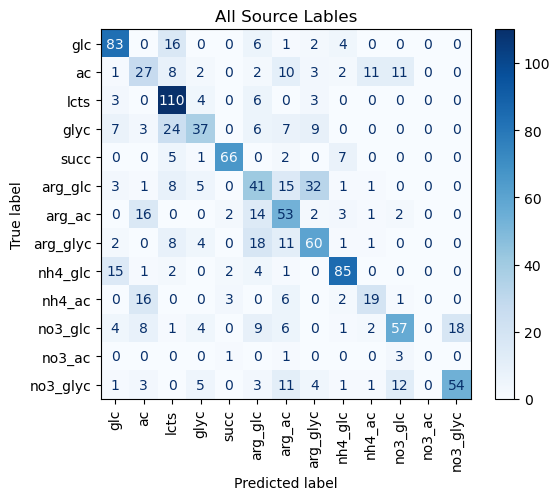

In [121]:
Y_pred_val = base_rf.predict(X_val)

env_order = ['glc', 'ac', 'lcts', 'glyc', 'succ', 'arg_glc', 'arg_ac', 'arg_glyc',
             'nh4_glc', 'nh4_ac', 'no3_glc', 'no3_ac', 'no3_glyc']

cm = confusion_matrix(le_1.inverse_transform(Y_val_source), 
                      le_1.inverse_transform(Y_pred_val),
                      labels=env_order)

disp = ConfusionMatrixDisplay(cm, display_labels=env_order)

disp.plot(cmap='Blues', xticks_rotation=90)
plt.title("All Source Lables")
plt.show()

In [122]:
print(classification_report(
    Y_val_source,
    Y_pred_val,
    target_names=le_1.classes_
))

              precision    recall  f1-score   support

          ac       0.36      0.35      0.36        77
      arg_ac       0.43      0.57      0.49        93
     arg_glc       0.38      0.38      0.38       107
    arg_glyc       0.52      0.57      0.55       105
         glc       0.70      0.74      0.72       112
        glyc       0.60      0.40      0.48        93
        lcts       0.60      0.87      0.71       126
      nh4_ac       0.53      0.40      0.46        47
     nh4_glc       0.79      0.77      0.78       110
      no3_ac       0.00      0.00      0.00         5
     no3_glc       0.66      0.52      0.58       110
    no3_glyc       0.75      0.57      0.65        95
        succ       0.89      0.81      0.85        81

    accuracy                           0.60      1161
   macro avg       0.55      0.54      0.54      1161
weighted avg       0.60      0.60      0.59      1161



/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

### 2. Limiting nutrient

In [123]:
Y_train_2 = Y_train['source'].str.split('_').str[0]
Y_val_2 = Y_val['source'].str.split('_').str[0]

le_2 = LabelEncoder()

Y_train_source2 = le_2.fit_transform(Y_train_2)
Y_val_source2 = le_2.transform(Y_val_2)

In [124]:
base_rf.fit(X_train, Y_train_source2)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

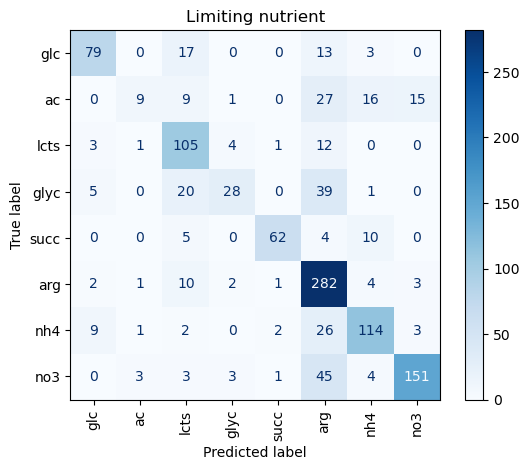

In [125]:
Y_pred_val2 = base_rf.predict(X_val)

env_order = ['glc', 'ac', 'lcts', 'glyc', 'succ', 'arg', 'nh4', 'no3']

cm = confusion_matrix(le_2.inverse_transform(Y_val_source2), 
                      le_2.inverse_transform(Y_pred_val2),
                      labels=env_order)

disp = ConfusionMatrixDisplay(cm, display_labels=env_order)

disp.plot(cmap='Blues', xticks_rotation=90)
plt.title("Limiting nutrient")
plt.show()

In [126]:
print(classification_report(
    Y_val_source2,
    Y_pred_val2,
    target_names=le_2.classes_
))

              precision    recall  f1-score   support

          ac       0.60      0.12      0.20        77
         arg       0.63      0.92      0.75       305
         glc       0.81      0.71      0.75       112
        glyc       0.74      0.30      0.43        93
        lcts       0.61      0.83      0.71       126
         nh4       0.75      0.73      0.74       157
         no3       0.88      0.72      0.79       210
        succ       0.93      0.77      0.84        81

    accuracy                           0.71      1161
   macro avg       0.74      0.64      0.65      1161
weighted avg       0.73      0.71      0.69      1161



### 3. Binary

In [145]:
Y_train_3 = Y_train['source'].str.contains(r'arg|nh4|no3', case=False, na=False).map({True: 'Nitrogen', False: 'Carbon'})
Y_val_3 = Y_val['source'].str.contains(r'arg|nh4|no3', case=False, na=False).map({True: 'Nitrogen', False: 'Carbon'})

le3 = LabelEncoder()
Y_train_bin = le3.fit_transform(Y_train_3)
Y_val_bin = le3.transform(Y_val_3)

In [128]:
base_rf.fit(X_train, Y_train_bin)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

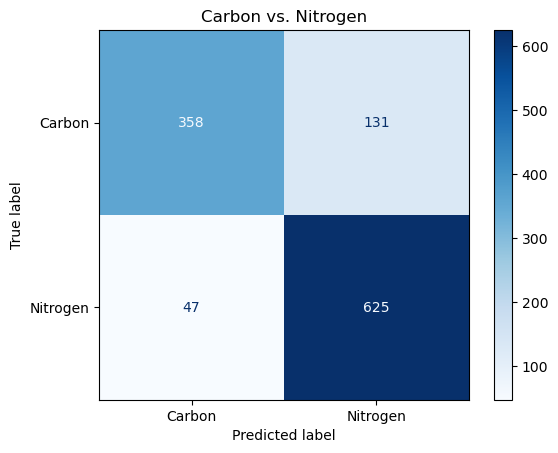

In [129]:
Y_pred_val_3 = base_rf.predict(X_val)

cm = confusion_matrix(Y_val_bin, Y_pred_val_3)
disp = ConfusionMatrixDisplay(cm, display_labels=le3.classes_)

disp.plot(cmap='Blues')
plt.title("Carbon vs. Nitrogen")
plt.show()

In [131]:
accuracy = accuracy_score(Y_val_bin, Y_pred_val_3)
precision = precision_score(Y_val_bin, Y_pred_val_3)
recall = recall_score(Y_val_bin, Y_pred_val_3)
f1 = f1_score(Y_val_bin, Y_pred_val_3)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

Accuracy:  0.847
Precision: 0.827
Recall:    0.930
F1-score:  0.875


### 4. Carbon and Nitrogen separate

In [154]:
X_train_c = X_train[Y_train_3 == 'Carbon']
X_val_c = X_val[Y_val_3 == 'Carbon']

Y_train_c = Y_train[Y_train_3 == 'Carbon']
Y_val_c = Y_val[Y_val_3 == 'Carbon']

#######################################################
X_train_n = X_train[Y_train_3 == 'Nitrogen']
X_val_n = X_val[Y_val_3 == 'Nitrogen']

Y_train_n = Y_train[Y_train_3 == 'Nitrogen']
Y_val_n = Y_val[Y_val_3 == 'Nitrogen']

In [155]:
Y_train_c = Y_train_c['source']
Y_val_c = Y_val_c['source']

le_c = LabelEncoder()

Y_train_enc_c = le_c.fit_transform(Y_train_c)
Y_val_enc_c = le_c.fit_transform(Y_val_c)

#########################################

le_n = LabelEncoder()

# Y_train_n = Y_train_n['source']
# Y_val_n = Y_val_n['source']
Y_train_n = Y_train_n['source'].str.split('_').str[0]
Y_val_n = Y_val_n['source'].str.split('_').str[0]

Y_train_enc_n = le_n.fit_transform(Y_train_n)
Y_val_enc_n = le_n.fit_transform(Y_val_n)

**CARBON**

In [156]:
base_rf.fit(X_train_c, Y_train_enc_c)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

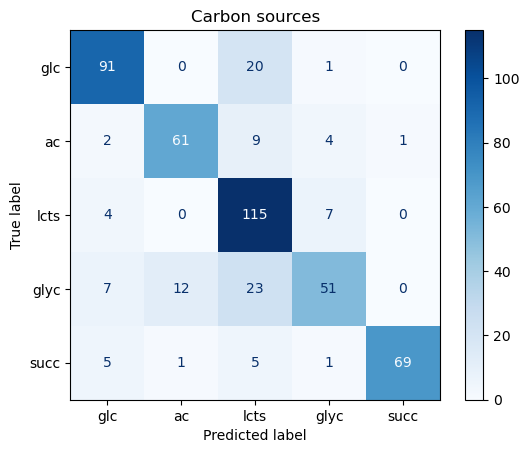

In [157]:
Y_pred_val_c = base_rf.predict(X_val_c)

env_order = ['glc', 'ac', 'lcts', 'glyc', 'succ']

cm = confusion_matrix(le_c.inverse_transform(Y_val_enc_c), 
                      le_c.inverse_transform(Y_pred_val_c),
                      labels=env_order)

disp = ConfusionMatrixDisplay(cm, display_labels=env_order)

disp.plot(cmap='Blues')
plt.title("Carbon sources")
plt.show()

In [137]:
print(classification_report(
    Y_val_enc_c,
    Y_pred_val_c,
    target_names=le_c.classes_
))

              precision    recall  f1-score   support

          ac       0.82      0.79      0.81        77
         glc       0.83      0.81      0.82       112
        glyc       0.80      0.55      0.65        93
        lcts       0.67      0.91      0.77       126
        succ       0.99      0.85      0.91        81

    accuracy                           0.79       489
   macro avg       0.82      0.78      0.79       489
weighted avg       0.81      0.79      0.79       489



**NITROGEN**

In [149]:
base_rf.fit(X_train_n, Y_train_enc_n)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

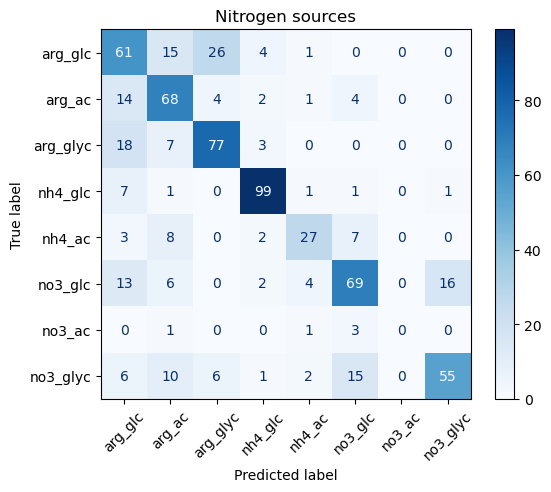

In [152]:
Y_pred_val_n = base_rf.predict(X_val_n)

env_order = ['arg_glc', 'arg_ac', 'arg_glyc',
             'nh4_glc', 'nh4_ac', 'no3_glc', 'no3_ac', 'no3_glyc']

cm = confusion_matrix(le_n.inverse_transform(Y_val_enc_n), 
                      le_n.inverse_transform(Y_pred_val_n),
                      labels=env_order)

disp = ConfusionMatrixDisplay(cm, display_labels=env_order)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Nitrogen sources")
plt.show()

In [153]:
print(classification_report(
    Y_val_enc_n,
    Y_pred_val_n,
    target_names=le_n.classes_
))

              precision    recall  f1-score   support

      arg_ac       0.59      0.73      0.65        93
     arg_glc       0.50      0.57      0.53       107
    arg_glyc       0.68      0.73      0.71       105
      nh4_ac       0.73      0.57      0.64        47
     nh4_glc       0.88      0.90      0.89       110
      no3_ac       0.00      0.00      0.00         5
     no3_glc       0.70      0.63      0.66       110
    no3_glyc       0.76      0.58      0.66        95

    accuracy                           0.68       672
   macro avg       0.60      0.59      0.59       672
weighted avg       0.68      0.68      0.68       672



/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

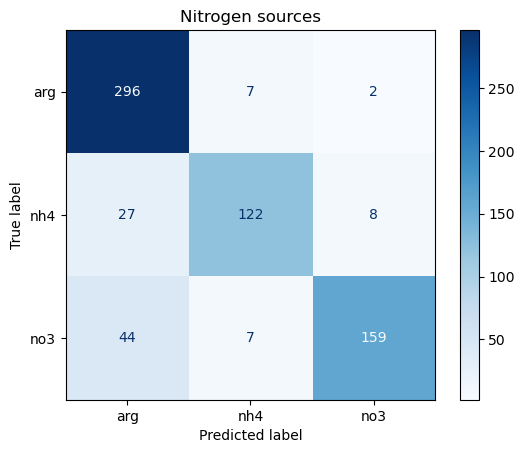

In [141]:
Y_pred_val_n = base_rf.predict(X_val_n)

env_order = ['arg', 'nh4', 'no3']

cm = confusion_matrix(le_n.inverse_transform(Y_val_enc_n), 
                      le_n.inverse_transform(Y_pred_val_n),
                      labels=env_order)

disp = ConfusionMatrixDisplay(cm, display_labels=env_order)

disp.plot(cmap='Blues')
plt.title("Nitrogen sources")
plt.show()

In [ ]:
print(classification_report(
    Y_val_enc_n,
    Y_pred_val_n,
    target_names=le_n.classes_
))

              precision    recall  f1-score   support

         arg       0.81      0.97      0.88       305
         nh4       0.90      0.78      0.83       157
         no3       0.94      0.76      0.84       210

    accuracy                           0.86       672
   macro avg       0.88      0.83      0.85       672
weighted avg       0.87      0.86      0.86       672

